## Adherence per months

In [1]:
import pandas as pd

In [3]:
pdc=pd.read_csv(r"C:\Users\laiar\Desktop\Classe IDIBAPS\data_sintetica\Data-sintetica\Data-sintetica\src\csv merged\pdc_per_patient_year.csv")

In [5]:
pdc['first_lai_date'] = pd.to_datetime(pdc['first_lai_date'])
# Filter by 3 years of data before switching and after
switchers_post2016 = pdc[
    (pdc['switcher'] == True) & 
    (pdc['first_lai_date'].dt.year >= 2016)
]['idCas'].unique()

print(f"N switchers from 2016 onwards: {len(switchers_post2016)}")

pdc_2016 = pdc[
    (pdc['idCas'].isin(switchers_post2016)) & 
    (pdc['year'].between(2013, 2019))
]

print(pdc_2016['year'].value_counts().sort_index())

N switchers from 2016 onwards: 1275
year
2013     749
2014     864
2015     965
2016    1098
2017    1187
2018    1249
2019    1275
Name: count, dtype: int64


In [6]:
# PDC monthly

# Reload dispensing tables
df_23_dispensats = pd.read_csv(r"C:\Users\laiar\Desktop\DATOS_PADRIS_nets\23_antipsicotics_dispensats.csv")
df_25_mhda = pd.read_csv(r"C:\Users\laiar\Desktop\DATOS_PADRIS_nets\25_taula_farmacs_mhda_2010_2019_Final.csv")

# Filter to the 1275 patients
df_23_2016 = df_23_dispensats[df_23_dispensats['idCas'].isin(switchers_post2016)]
df_25_2016 = df_25_mhda[df_25_mhda['idCas'].isin(switchers_post2016)]

print(df_23_2016.shape)
print(df_25_2016.shape)

C:\Users\laiar\AppData\Local\Temp\ipykernel_3260\846361285.py:4: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df_23_dispensats = pd.read_csv(r"C:\Users\laiar\Desktop\DATOS_PADRIS_nets\23_antipsicotics_dispensats.csv")


(140246, 20)
(2501, 13)


In [7]:
LAI_INTERVALS = {
    # ABILIFY MAINTENA — 28 days
    'ABILIFY MAINTENA 400MG 1 VIAL POLVO +1 VIAL DISOLV SUSPENS LIBER PROLONG': 28,
    'ABILIFY MAINTENA 300MG 1 VIAL POLVO +1 VIAL DISOLV SUSPENS LIBER PROLONG': 28,
    # TREVICTA — 84 days
    'TREVICTA 175MG 1 JERINGA PREC 0,875ML SUSP INYECT LIBERACION PROL': 84,
    'TREVICTA 350MG 1 JERINGA PRECARGADA 1,750ML SUSP INY LIBER PROLONG': 84,
    'TREVICTA 525MG 1 JERINGA PRECARGADA 2,625ML SUSP INY LIBER PROLONG': 84,
    'TREVICTA 263MG 1 JERINGA PREC 1,315ML + 2 AGUJAS SUSP INY LIBER PROL': 84,
    # XEPLION — 28 days
    'XEPLION 50MG 1 JERINGA PRECARG 0,5ML SUSPEN INYEC LIBERAC PROLONG': 28,
    'XEPLION 75MG 1 JERINGA PRECARG 0,75ML SUSPEN INYEC LIBERAC PROLONG': 28,
    'XEPLION 100MG 1 JERINGA PRECARG 1ML SUSPENS INYEC LIBERAC PROLONG': 28,
    'XEPLION 150MG 1 JERINGA PRECARG 1,5ML SUSPEN INYEC LIBERAC PROLONG': 28,
    'XEPLION 50MG 1 JER PREC + 2 AGU SUSPENS INYECT LIBERACION PROLONGADA': 28,
    'XEPLION 75MG 1 JER PREC + 2 AGU SUSPENS INYECT LIBERACION PROLONGADA': 28,
    'XEPLION 100MG 1 JER PREC + 2 AGU SUSPENS INYECT LIBERACION PROLONGADA': 28,
    'XEPLION 150MG 1 JER PREC + 2 AGU SUSPENS INYECT LIBERACION PROLONGADA': 28,
    # RISPERDAL CONSTA — 14 days
    'RISPERDAL CONSTA 25MG/VIAL 1 VIAL + 1 JER PRECARG': 14,
    'RISPERDAL CONSTA 37,5MG/VIAL 1 VIAL + 1 JER PRECAR': 14,
    'RISPERDAL CONSTA 50MG/VIAL 1 VIAL + 1 JER PRECARG': 14,
    'ZYPADHERA 210MG 1 VIAL POLVO + 1 VIAL DISOLV SUSP INY LIBERAC PROLONG': 14,
    # ZYPADHERA — 28 days,
    'ZYPADHERA 300MG 1 VIAL POLVO + 1 VIAL DISOLV SUSP INY LIBERAC PROLONG': 28,
    'ZYPADHERA 405MG 1 VIAL POLVO + 1 VIAL DISOLV SUSP INY LIBERAC PROLONG': 28,
    # HALDOL DECANOATE — 28 days
    'HALDOL DECANOATE 100 mg/ml 1 Solución inyectable': 28,
    'HALDOL DEPOT 5 AMP. 100 MG.': 28

}

IMMEDIATE_ACTION = [
    'HALOPERIDOL ESTEVE 5MG/ML 5 AMPOLLAS INYECTABLE',
    'DOGMATIL 50MG/ML 12 AMPOLLAS 2ML SOLUCION INYECTABLE',
    'DOGMATIL 50MG/ML SOLUCION INYECTABLE 12 AMPOLLAS DE 2ML',
    'DOGMATIL 50 mg/ml  5 Soluc inyect/CSE013078',
    'ZYPREXA 10MG 1 VIAL POLVO PARA SOLUCION INYECTABLE',
    'ABILIFY 7,5MG/ML 1 VIAL 1,3ML SOLUCION INYECTABLE',
]

In [8]:
def classify_product(product_name):
    if product_name in LAI_INTERVALS:
        return 'LAI'
    elif product_name in IMMEDIATE_ACTION:
        return 'IMMEDIATE_ACTION'
    else:
        return 'ORAL'

def anymes_to_date(anymes):
    anymes = str(int(anymes))
    return pd.Timestamp(year=int(anymes[:4]), month=int(anymes[4:]), day=15)

# Table 23
df_23_2016 = df_23_dispensats[df_23_dispensats['idCas'].isin(switchers_post2016)].copy()
df_23_2016['formulation_type'] = df_23_2016['DES_HIS_Producte'].apply(classify_product)
df_23_2016['dispensing_date'] = df_23_2016['Any_Mes'].apply(anymes_to_date)
df_23_2016['days_coverage'] = df_23_2016.apply(
    lambda row: LAI_INTERVALS[row['DES_HIS_Producte']] 
    if row['formulation_type'] == 'LAI' 
    else (float(str(row['Nombre_DDD_Receptes_Dispensades']).replace(',', '.')) 
          if row['formulation_type'] == 'ORAL' else 0),
    axis=1
)

# Table 25
df_25_2016 = df_25_mhda[df_25_mhda['idCas'].isin(switchers_post2016)].copy()
df_25_2016['formulation_type'] = df_25_2016['(HIS) Producte Desc'].apply(classify_product)
df_25_2016['dispensing_date'] = df_25_2016['Any_Mes'].apply(anymes_to_date)
df_25_2016['days_coverage'] = df_25_2016.apply(
    lambda row: LAI_INTERVALS[row['(HIS) Producte Desc']] 
    if row['formulation_type'] == 'LAI' else 0,
    axis=1
)

print(df_23_2016['formulation_type'].value_counts())
print(df_25_2016['formulation_type'].value_counts())

formulation_type
ORAL                84123
LAI                 56024
IMMEDIATE_ACTION       99
Name: count, dtype: int64
formulation_type
ORAL    2307
LAI      194
Name: count, dtype: int64


In [9]:
import calendar

def merge_intervals(intervals):
    if not intervals:
        return []
    sorted_intervals = sorted(intervals, key=lambda x: x[0])
    result = [sorted_intervals[0]]
    for start, end in sorted_intervals[1:]:
        prev_end = result[-1][1]
        if start <= prev_end:
            leftover = (prev_end - start).days + 1
            new_end = end + pd.Timedelta(days=leftover)
            result.append((prev_end + pd.Timedelta(days=1), new_end))
        else:
            result.append((start, end))
    return result

def days_covered_in_month(intervals, year, month, treatment_start):
    month_start = pd.Timestamp(year, month, 1)
    month_end = pd.Timestamp(year, month, calendar.monthrange(year, month)[1])
    
    # Adjust start for first month of treatment
    effective_start = max(month_start, treatment_start)
    if effective_start > month_end:
        return None, None  # patient not yet in treatment
    
    denominator = (month_end - effective_start).days + 1
    
    covered = 0
    for start, end in intervals:
        overlap_start = max(start, effective_start)
        overlap_end = min(end, month_end)
        if overlap_start <= overlap_end:
            covered += (overlap_end - overlap_start).days + 1
    
    return min(covered, denominator), denominator

def compute_monthly_pdc(patient_df_23, patient_df_25, treatment_start):
    results = []
    
    oral_intervals = []
    for _, row in patient_df_23[patient_df_23['formulation_type'] == 'ORAL'].iterrows():
        start = row['dispensing_date']
        end = start + pd.Timedelta(days=int(row['days_coverage']) - 1)
        oral_intervals.append((start, end))
    
    lai_intervals = []
    for _, row in patient_df_23[patient_df_23['formulation_type'] == 'LAI'].iterrows():
        start = row['dispensing_date']
        end = start + pd.Timedelta(days=int(row['days_coverage']) - 1)
        lai_intervals.append((start, end))
    for _, row in patient_df_25[patient_df_25['formulation_type'] == 'LAI'].iterrows():
        start = row['dispensing_date']
        end = start + pd.Timedelta(days=int(row['days_coverage']) - 1)
        lai_intervals.append((start, end))
    
    oral_merged = merge_intervals(oral_intervals)
    lai_merged = merge_intervals(lai_intervals)
    total_merged = merge_intervals(oral_intervals + lai_intervals)
    
    for year in range(treatment_start.year, 2020):
        for month in range(1, 13):
            oral_covered, denominator = days_covered_in_month(oral_merged, year, month, treatment_start)
            if oral_covered is None:
                continue
            lai_covered, _ = days_covered_in_month(lai_merged, year, month, treatment_start)
            total_covered, _ = days_covered_in_month(total_merged, year, month, treatment_start)
            
            results.append({
                'year': year,
                'month': month,
                'year_month': f"{year}-{month:02d}",
                'denominator': denominator,
                'PDC_oral': round(oral_covered / denominator, 4),
                'PDC_lai': round(lai_covered / denominator, 4),
                'PDC_total': round(total_covered / denominator, 4),
            })
    
    return pd.DataFrame(results)

In [10]:
all_results_monthly = []

for patient_id in switchers_post2016:
    p23 = df_23_2016[df_23_2016['idCas'] == patient_id]
    p25 = df_25_2016[df_25_2016['idCas'] == patient_id]
    
    dates = []
    if not p23.empty:
        dates.append(p23['dispensing_date'].min())
    if not p25.empty:
        dates.append(p25['dispensing_date'].min())
    
    if not dates:
        continue
    
    treatment_start = min(dates)
    
    pdc_df = compute_monthly_pdc(p23, p25, treatment_start)
    pdc_df['idCas'] = patient_id
    all_results_monthly.append(pdc_df)

pdc_monthly = pd.concat(all_results_monthly, ignore_index=True)
pdc_monthly = pdc_monthly.sort_values(['idCas', 'year', 'month']).reset_index(drop=True)

print(pdc_monthly.shape)
print(pdc_monthly.head(20))

(96196, 8)
    year  month year_month  denominator  PDC_oral  PDC_lai  PDC_total  \
0   2019      2    2019-02           14    1.0000   0.0000     1.0000   
1   2019      3    2019-03           31    0.1290   0.0000     0.1290   
2   2019      4    2019-04           30    0.5333   0.0000     0.5333   
3   2019      5    2019-05           31    1.0000   0.0000     1.0000   
4   2019      6    2019-06           30    1.0000   0.0000     1.0000   
5   2019      7    2019-07           31    1.0000   0.0000     1.0000   
6   2019      8    2019-08           31    1.0000   0.0000     1.0000   
7   2019      9    2019-09           30    1.0000   0.0000     1.0000   
8   2019     10    2019-10           31    1.0000   0.0000     1.0000   
9   2019     11    2019-11           30    1.0000   0.5333     1.0000   
10  2019     12    2019-12           31    1.0000   1.0000     1.0000   
11  2019      2    2019-02           14    1.0000   0.0000     1.0000   
12  2019      3    2019-03           31 

In [12]:
pdc_monthly = pdc_monthly[['idCas', 'year', 'month', 'year_month', 'denominator', 'PDC_oral', 'PDC_lai', 'PDC_total']]
pdc_monthly.to_csv(r'C:\Users\laiar\Desktop\Classe IDIBAPS\data_sintetica\Data-sintetica\Data-sintetica\src\csv merged\pdc_monthly_switchers_2016.csv', index=False)
print("Saved!")

Saved!


In [13]:
# Add switch date to monthly data
switch_dates = pdc[pdc['switcher'] == True][['idCas', 'first_lai_date']].drop_duplicates()
switch_dates['first_lai_date'] = pd.to_datetime(switch_dates['first_lai_date'])

pdc_monthly = pdc_monthly.merge(switch_dates, on='idCas', how='left')

# Calculate months relative to switch
pdc_monthly['switch_year'] = pdc_monthly['first_lai_date'].dt.year
pdc_monthly['switch_month'] = pdc_monthly['first_lai_date'].dt.month

pdc_monthly['months_to_switch'] = (
    (pdc_monthly['year'] - pdc_monthly['switch_year']) * 12 + 
    (pdc_monthly['month'] - pdc_monthly['switch_month'])
)

# Filter to -36 to +36 months
pdc_monthly_aligned = pdc_monthly[pdc_monthly['months_to_switch'].between(-36, 36)]

print(pdc_monthly_aligned['months_to_switch'].value_counts().sort_index())

months_to_switch
-36    832
-35    842
-34    849
-33    855
-32    865
      ... 
 32    490
 33    463
 34    430
 35    397
 36    367
Name: count, Length: 73, dtype: int64


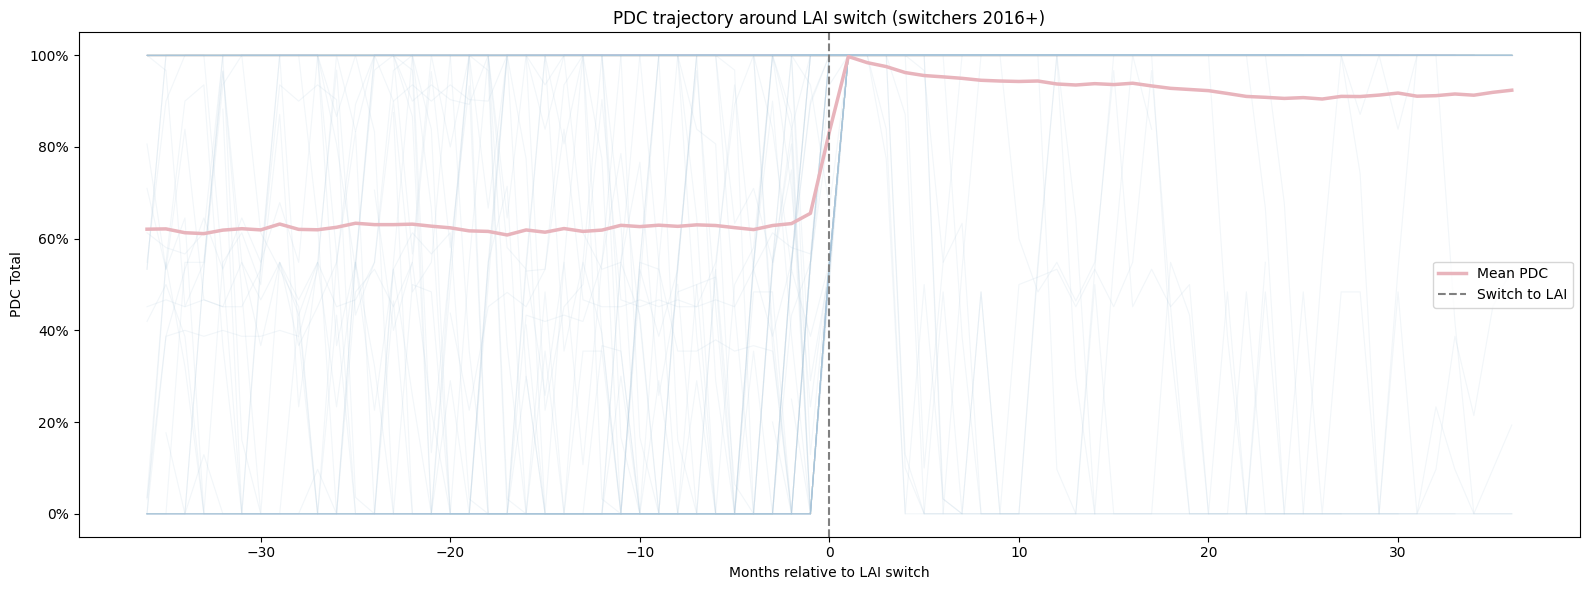

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

custom2 = ['#E8B4BC', '#B7C9A8', '#A8C5DA', '#D4B8D4', '#F0D9B5']

# Mean trajectory
mean_traj = pdc_monthly_aligned.groupby('months_to_switch')['PDC_total'].mean().reset_index()

fig, ax = plt.subplots(figsize=(16, 6))

# Spaghetti — individual trajectories (sample to avoid overplotting)
sample_ids = pdc_monthly_aligned['idCas'].drop_duplicates().sample(100, random_state=42)
for patient_id in sample_ids:
    patient_data = pdc_monthly_aligned[pdc_monthly_aligned['idCas'] == patient_id]
    ax.plot(patient_data['months_to_switch'], patient_data['PDC_total'], 
            color='#A8C5DA', alpha=0.15, linewidth=0.8)

# Mean line on top
ax.plot(mean_traj['months_to_switch'], mean_traj['PDC_total'], 
        color='#E8B4BC', linewidth=2.5, label='Mean PDC')

# Switch line
ax.axvline(x=0, color='grey', linestyle='--', label='Switch to LAI')

ax.set_xlabel('Months relative to LAI switch')
ax.set_ylabel('PDC Total')
ax.set_title('PDC trajectory around LAI switch (switchers 2016+)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
ax.legend()

plt.tight_layout()
plt.savefig(r'C:\Users\laiar\Desktop\Classe IDIBAPS\data_sintetica\Data-sintetica\Data-sintetica\src\EDA\pdc_monthly_trajectory.png', dpi=150)
plt.show()

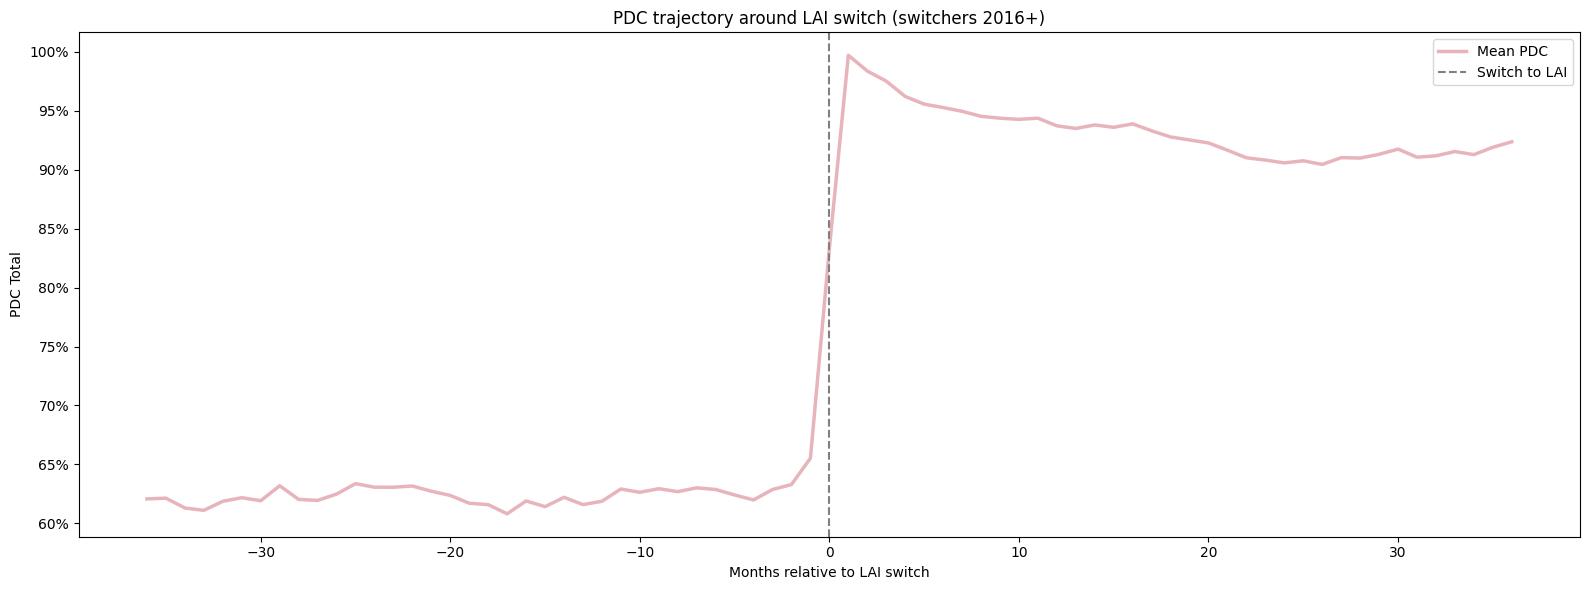

In [15]:
# Just the mean
fig, ax = plt.subplots(figsize=(16, 6))

# Mean line only
ax.plot(mean_traj['months_to_switch'], mean_traj['PDC_total'], 
        color='#E8B4BC', linewidth=2.5, label='Mean PDC')

# Switch line
ax.axvline(x=0, color='grey', linestyle='--', label='Switch to LAI')

ax.set_xlabel('Months relative to LAI switch')
ax.set_ylabel('PDC Total')
ax.set_title('PDC trajectory around LAI switch (switchers 2016+)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
ax.legend()

plt.tight_layout()
plt.savefig(r'C:\Users\laiar\Desktop\Classe IDIBAPS\data_sintetica\Data-sintetica\Data-sintetica\src\EDA\pdc_monthly_mean.png', dpi=150)
plt.show()

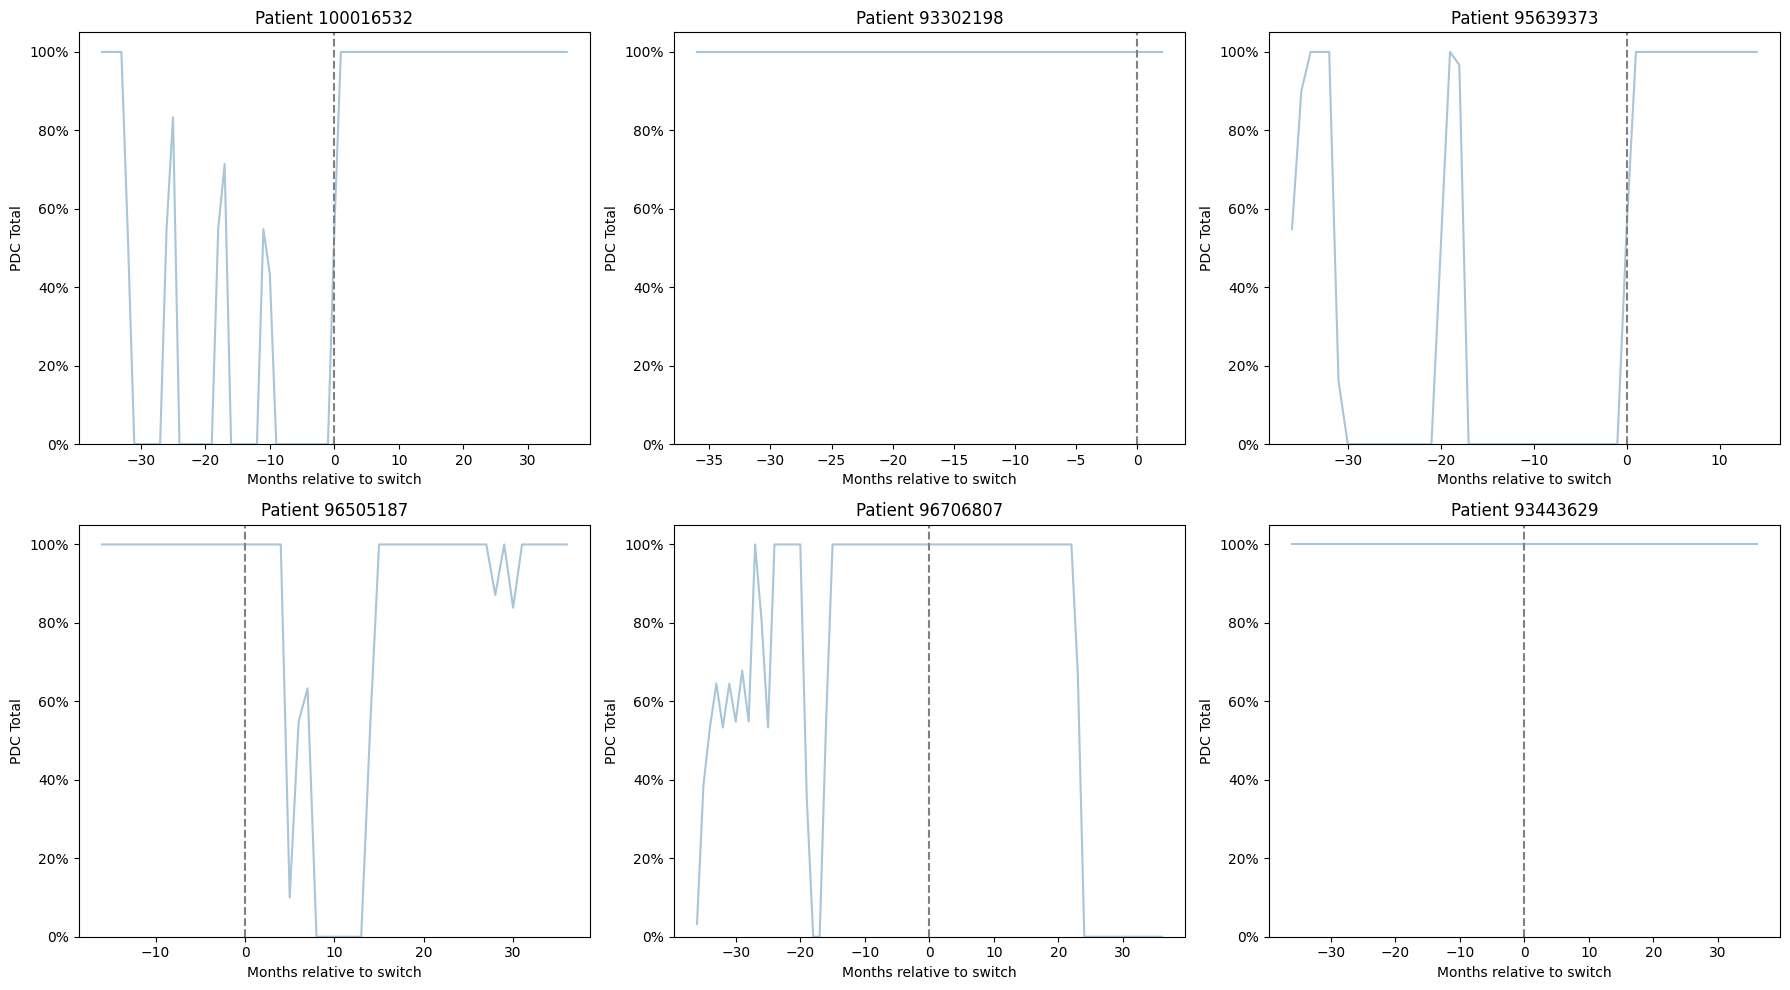

In [16]:
# Plot of several random patients
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

sample_ids = pdc_monthly_aligned['idCas'].drop_duplicates().sample(6, random_state=42)

for i, patient_id in enumerate(sample_ids):
    patient_data = pdc_monthly_aligned[pdc_monthly_aligned['idCas'] == patient_id]
    axes[i].plot(patient_data['months_to_switch'], patient_data['PDC_total'], 
                 color='#A8C5DA', linewidth=1.5)
    axes[i].axvline(x=0, color='grey', linestyle='--')
    axes[i].set_title(f'Patient {patient_id}')
    axes[i].set_xlabel('Months relative to switch')
    axes[i].set_ylabel('PDC Total')
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
    axes[i].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(r'C:\Users\laiar\Desktop\Classe IDIBAPS\data_sintetica\Data-sintetica\Data-sintetica\src\EDA\pdc_random_patients.png', dpi=150)
plt.show()

In [19]:
# Flagging missed injections
# Get all LAI dispensing events for switchers
lai_events_23 = df_23_2016[df_23_2016['formulation_type'] == 'LAI'][['idCas', 'dispensing_date', 'DES_HIS_Producte', 'days_coverage']]
lai_events_25 = df_25_2016[df_25_2016['formulation_type'] == 'LAI'][['idCas', 'dispensing_date', '(HIS) Producte Desc', 'days_coverage']]

# Rename to common column names
lai_events_23 = lai_events_23.rename(columns={'DES_HIS_Producte': 'product'})
lai_events_25 = lai_events_25.rename(columns={'(HIS) Producte Desc': 'product'})

lai_all = pd.concat([lai_events_23, lai_events_25]).sort_values(['idCas', 'dispensing_date']).reset_index(drop=True)

# Calculate gaps per patient
records = []
for patient_id, group in lai_all.groupby('idCas'):
    group = group.sort_values('dispensing_date').reset_index(drop=True)
    for i in range(len(group) - 1):
        expected_next = group.loc[i, 'dispensing_date'] + pd.Timedelta(days=int(group.loc[i, 'days_coverage']))
        actual_next = group.loc[i+1, 'dispensing_date']
        gap_days = (actual_next - expected_next).days
        gap_weeks = gap_days / 7
        missed = gap_days > 14
        
        records.append({
            'idCas': patient_id,
            'injection_date': group.loc[i, 'dispensing_date'],
            'expected_next': expected_next,
            'actual_next': actual_next,
            'gap_days': gap_days,
            'gap_weeks': round(gap_weeks, 2),
            'missed': missed,
            'product': group.loc[i, 'product']
        })

gaps_df = pd.DataFrame(records)

# Add switch year
gaps_df = gaps_df.merge(switch_dates[['idCas', 'first_lai_date']], on='idCas', how='left')
gaps_df['switch_year'] = pd.to_datetime(gaps_df['first_lai_date']).dt.year
gaps_df['pre_post'] = gaps_df.apply(
    lambda row: 'post' if row['injection_date'] >= row['first_lai_date'] else 'pre', axis=1
)

print(gaps_df.head(10))
print(f"\nMissed injections: {gaps_df['missed'].sum()} / {len(gaps_df)} ({gaps_df['missed'].mean()*100:.1f}%)")
print(f"\nMean gap pre-switch: {gaps_df[gaps_df['pre_post']=='pre']['gap_weeks'].mean():.2f} weeks")
print(f"Mean gap post-switch: {gaps_df[gaps_df['pre_post']=='post']['gap_weeks'].mean():.2f} weeks")

      idCas injection_date expected_next actual_next  gap_days  gap_weeks  \
0  75851283     2019-11-15    2019-12-13  2019-11-15       -28      -4.00   
1  75851283     2019-11-15    2019-12-13  2019-11-15       -28      -4.00   
2  75851283     2019-11-15    2019-12-13  2019-11-15       -28      -4.00   
3  75851283     2019-11-15    2019-12-13  2019-12-15         2       0.29   
4  75851283     2019-12-15    2020-01-12  2019-12-15       -28      -4.00   
5  75851283     2019-12-15    2020-01-12  2019-12-15       -28      -4.00   
6  75851283     2019-12-15    2020-01-12  2019-12-15       -28      -4.00   
7  77532646     2019-10-15    2019-11-12  2019-10-15       -28      -4.00   
8  77532646     2019-10-15    2019-11-12  2019-10-15       -28      -4.00   
9  77532646     2019-10-15    2019-11-12  2019-10-15       -28      -4.00   

   missed                                            product first_lai_date  \
0   False  ABILIFY MAINTENA 400MG 1 VIAL POLVO +1 VIAL DI...     2019-11-

In [18]:
lai_all = lai_all.drop_duplicates(subset=['idCas', 'dispensing_date', 'product']).sort_values(['idCas', 'dispensing_date']).reset_index(drop=True)
print(lai_all.shape)

(19209, 4)
